<a href="https://colab.research.google.com/github/chandraPrakash-tripathi/CHURN-DATA-ANALYSIS/blob/master1/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries and Load Dataset


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


2. Data Exploration & Visualization

In [2]:
# Load your dataset
df = pd.read_csv("customer_churn_dataset.csv")  # replace with actual filename
print(df.head(2))  # Sanity check
print(df.info())   # Check datatypes and nulls


  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Cust_1    Male            0.0     Yes         No     2.0          Yes   
1     Cust_2  Female            1.0      No         No     NaN          Yes   

  MultipleLines InternetService OnlineSecurity         OnlineBackup  Churn  
0            No             NaN             No  No internet service      1  
1            No     Fiber optic            Yes                  Yes      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       10000 non-null  object 
 1   gender           9000 non-null   object 
 2   SeniorCitizen    9000 non-null   float64
 3   Partner          9000 non-null   object 
 4   Dependents       9000 non-null   object 
 5   tenure           9000 non-null   float64
 6   PhoneService     9000 non-null   object 
 7   Mult

Visualizations:
Distribution of target variable (churn)

Histograms for numerical features

Correlation heatmap:

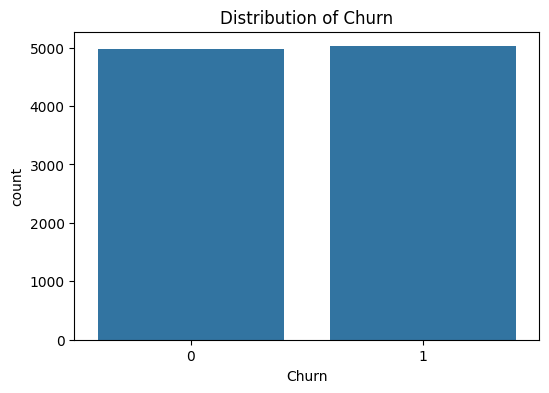

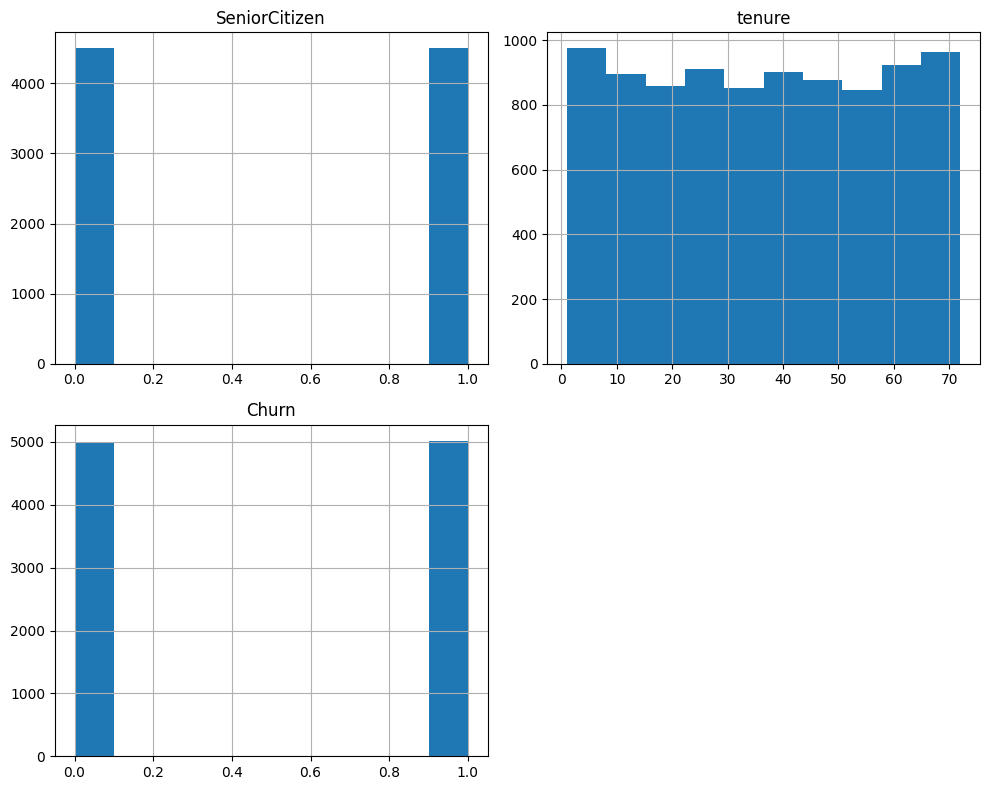

In [5]:
# Distribution of target variable (churn)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.show()

# Histograms for numerical features
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

3. Data Preprocessing & Cleaning

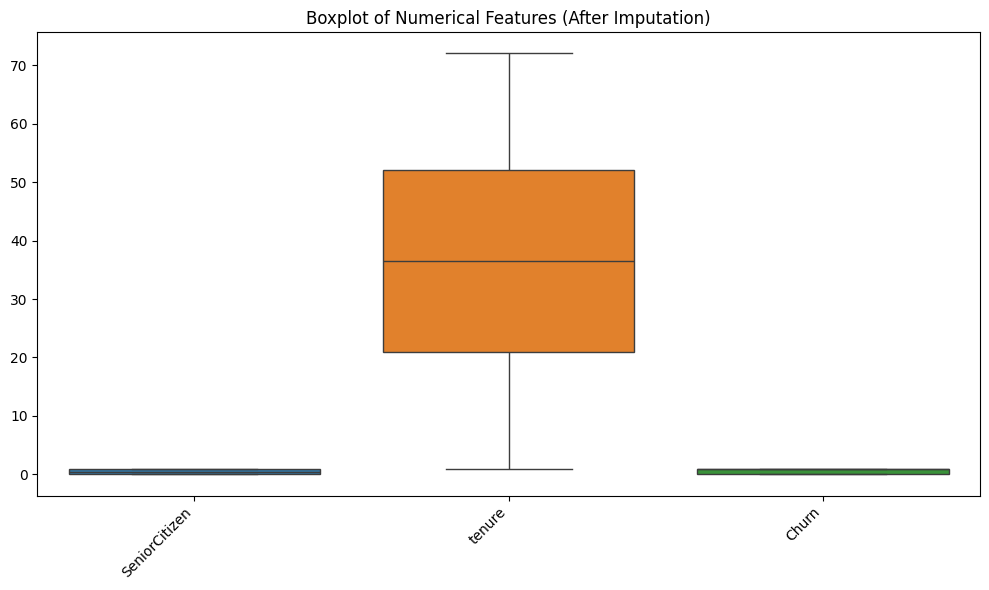

In [7]:
# Handling missing values
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

# Impute numerical columns with the mean
imputer_numeric = SimpleImputer(strategy='mean')
df[numerical_cols] = imputer_numeric.fit_transform(df[numerical_cols])

# Impute categorical columns with the most frequent value
imputer_categorical = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = imputer_categorical.fit_transform(df[categorical_cols])

# Optional: Detect outliers (can only be done on numerical data)
# Select only numerical columns for boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numerical_cols])
plt.title('Boxplot of Numerical Features (After Imputation)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

4. feature engineering


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#y = df_imputed["churn"] # y is already defined

Model Building

In [15]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Try 70-30 or 75-25 splits as well


In [16]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

# Ensemble: Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)


RandomForestClassifier()

Hyperparameter Tuning (GridSearchCV example):

In [17]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, None],
                         'n_estimators': [100, 200]})

Performance Evaluation

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

models = [lr, dt, knn, rf]
names = ["Logistic", "Decision Tree", "KNN", "Random Forest"]

for model, name in zip(models, names):
    y_pred = model.predict(X_test)
    print(f"\n{name} Report")
    print(classification_report(y_test, y_pred))
    print("AUC-ROC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))



Logistic Report
              precision    recall  f1-score   support

         0.0       0.50      0.50      0.50       985
         1.0       0.51      0.51      0.51      1015

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000

AUC-ROC: 0.507613212972919

Decision Tree Report
              precision    recall  f1-score   support

         0.0       0.50      0.50      0.50       985
         1.0       0.52      0.53      0.52      1015

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000

AUC-ROC: 0.5117551449076042

KNN Report
              precision    recall  f1-score   support

         0.0       0.50      0.52      0.51       985
         1.0       0.52      0.50      0.51      1015

    accuracy                           0.51      2000
   macro avg       0.5

Visualization

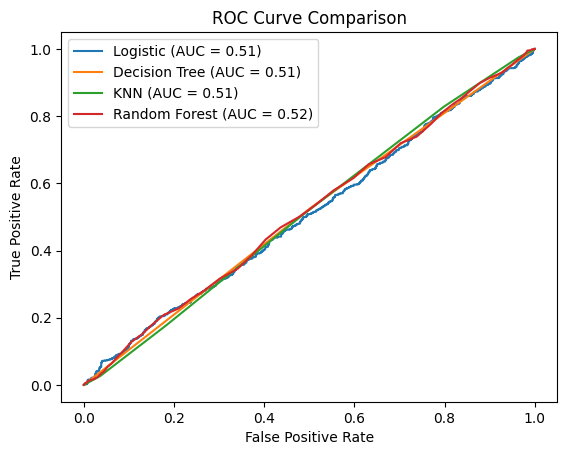

In [19]:
# ROC Curve
for model, name in zip(models, names):
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()
